# TSI vs SW Cloud Flag at Gothic

This notebook compares **TSI cloud fraction** to a **shortwave cloud flag** built from
observed incoming shortwave divided by a **Metsim clear-sky reference** at Gothic.

Rules used here:

- `SWobs / SWclr < 0.45` -> `cloudy`
- `SWobs / SWclr > 0.85` -> `clear`
- otherwise -> `ambiguous`
- evaluate only **9:00 AM to 2:00 PM local time** at Gothic, before the sun goes behind the mountain

Notes:

- TSI timestamps are treated as **UTC** and converted to `America/Denver`.
- The SW netCDF timestamps are treated as **local clock time** at Gothic.
- The Metsim clear-sky reference is built from `metsim.physics.solar_geom` and
  `metsim.disaggregate.shortwave` using an approximate Gothic elevation.
- Metsim's shortwave transmissivity constant (`TBASE`) is tuned with a known-clear
  satellite day, 2022-11-25; this is a shortwave transmission correction, not
  atmospheric emissivity.
- Metsim solar geometry is shifted onto the Gothic local clock, including the
  one-hour daylight-saving offset in `America/Denver`.


In [86]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from metsim import constants as metsim_constants
from metsim.physics import solar_geom
from metsim.disaggregate import shortwave as metsim_shortwave

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 16
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

TSI_CSV = "/glade/u/home/cdalden/scratch/surface_obs/colorado/sail_tsi_cloud_frac.csv"
SW_NC = "/glade/u/home/cdalden/scratch/surface_obs/colorado/sos_full_dataset_30min.nc"
SW_VAR = "Rsw_in_9m_d"

LOCAL_TZ = "America/Denver"
LOCAL_START = "09:00"
LOCAL_END = "14:00"
TIME_STEP_MIN = 30

GOTHIC_LAT = 38.96
GOTHIC_LON = -106.99
GOTHIC_ELEV_M = 2915.0
METSIM_LAPSE_RATE = 0.0065

CLOUDY_RATIO = 0.55
CLEAR_RATIO = 0.85

# November 25, 2022 is a known-clear satellite day. This TBASE value makes
# the 95th percentile of SWobs / SWclr on that day equal to about 1.0.
METSIM_TBASE = 0.90

In [87]:
def daylight_saving_offset_hours(days, local_tz):
    """Return the daylight-saving clock offset for each local date."""
    noons = pd.DatetimeIndex(days) + pd.Timedelta(hours=12)
    return np.array([
        noon.tz_localize(local_tz).dst().total_seconds() / 3600
        for noon in noons
    ])


def build_metsim_clear_sky(times_local, lat, lon, elev_m, lapse_rate, time_step_min, tbase, local_tz):
    """Build a Metsim-based clear-sky shortwave time series on the local clock."""
    metsim_constants.TBASE = tbase
    try:
        solar_geom.recompile()
    except AttributeError:
        pass
    solar = solar_geom(elev_m, lat, lapse_rate)
    tiny_rad_fract, daylength, flat_potrad, tt_max0 = solar

    all_days = pd.date_range(times_local.min().normalize(), times_local.max().normalize(), freq="D")
    yday_zero_based = all_days.dayofyear.to_numpy() - 1

    # Metsim's clear-sky daily potential uses potrad * tt_max0.
    clear_daily = flat_potrad[yday_zero_based] * tt_max0[yday_zero_based]

    params = {
        "time_step": time_step_min,
        "method": "mtclim",
        "utc_offset": False,
        "lon": lon,
    }

    clear_subdaily = metsim_shortwave(
        clear_daily,
        daylength[yday_zero_based],
        yday_zero_based + 1,
        tiny_rad_fract,
        params,
    )

    clear_times_solar = pd.date_range(all_days.min(), periods=len(clear_subdaily), freq=f"{time_step_min}min")
    day_offsets = pd.DataFrame({
        "date_solar": all_days,
        "dst_offset_hours": daylight_saving_offset_hours(all_days, local_tz),
    })
    clear_df = pd.DataFrame({"time_solar": clear_times_solar, "sw_clear": clear_subdaily})
    clear_df["date_solar"] = clear_df["time_solar"].dt.normalize()
    clear_df = clear_df.merge(day_offsets, on="date_solar", how="left")
    clear_df["time_local"] = clear_df["time_solar"] + pd.to_timedelta(clear_df["dst_offset_hours"], unit="h")
    return clear_df[["time_local", "sw_clear"]]


def pick_example_day(df):
    day_scores = (
        df.assign(date=df["time_local"].dt.normalize())
        .groupby("date")
        .agg(
            n=("time_local", "size"),
            n_clear=("sw_flag", lambda s: (s == "clear").sum()),
            n_cloudy=("sw_flag", lambda s: (s == "cloudy").sum()),
        )
    )
    day_scores["score"] = day_scores["n_clear"] * day_scores["n_cloudy"]
    return day_scores.sort_values(["score", "n"], ascending=False).index[0]


def frac_by_flag(series, label):
    return (series == label).mean()

In [88]:
sw_ds = xr.open_dataset(SW_NC)
sw_df = (
    sw_ds[SW_VAR]
    .to_dataframe()
    .reset_index()
    .rename(columns={"time": "time_local", SW_VAR: "sw_obs"})
)
sw_df["time_local"] = pd.to_datetime(sw_df["time_local"])
sw_df = sw_df[["time_local", "sw_obs"]].sort_values("time_local").reset_index(drop=True)

tsi_df = pd.read_csv(TSI_CSV, parse_dates=["t"])
tsi_df["time_local"] = (
    tsi_df["t"]
    .dt.tz_localize("UTC")
    .dt.tz_convert(LOCAL_TZ)
    .dt.tz_localize(None)
)
tsi_df = tsi_df[["time_local", "tsi_frac"]].sort_values("time_local").reset_index(drop=True)

tsi_30 = (
    tsi_df.set_index("time_local")
    .resample(f"{TIME_STEP_MIN}min")
    .mean()
    .reset_index()
)

overlap_start = max(sw_df["time_local"].min(), tsi_30["time_local"].min())
overlap_end = min(sw_df["time_local"].max(), tsi_30["time_local"].max())

sw_df = sw_df[(sw_df["time_local"] >= overlap_start) & (sw_df["time_local"] <= overlap_end)].copy()
tsi_30 = tsi_30[(tsi_30["time_local"] >= overlap_start) & (tsi_30["time_local"] <= overlap_end)].copy()

clear_df = build_metsim_clear_sky(
    times_local=sw_df["time_local"],
    lat=GOTHIC_LAT,
    lon=GOTHIC_LON,
    elev_m=GOTHIC_ELEV_M,
    lapse_rate=METSIM_LAPSE_RATE,
    time_step_min=TIME_STEP_MIN,
    tbase=METSIM_TBASE,
    local_tz=LOCAL_TZ,
)

compare_df = (
    sw_df.merge(clear_df, on="time_local", how="inner")
    .merge(tsi_30, on="time_local", how="inner")
    .sort_values("time_local")
    .reset_index(drop=True)
)

compare_df = compare_df.set_index("time_local").between_time(LOCAL_START, LOCAL_END, inclusive="both").reset_index()
compare_df.loc[compare_df["sw_clear"] <= 0, "sw_clear"] = np.nan

compare_df["sw_ratio"] = compare_df["sw_obs"] / compare_df["sw_clear"]

compare_df["sw_flag"] = np.select(
    [
        compare_df["sw_ratio"] < CLOUDY_RATIO,
        compare_df["sw_ratio"] > CLEAR_RATIO,
    ],
    [
        "cloudy",
        "clear",
    ],
    default="ambiguous",
)

compare_df["date"] = compare_df["time_local"].dt.normalize()
compare_df

,time_local,sw_obs,sw_clear,tsi_frac,sw_ratio,sw_flag,date
0,2022-11-01 09:00:00,285.936615,290.167270,0.006840,0.985420,clear,2022-11-01
1,2022-11-01 09:30:00,370.721100,380.405817,0.014510,0.974541,clear,2022-11-01
2,2022-11-01 10:00:00,424.712524,460.826739,0.041860,0.921632,clear,2022-11-01
3,2022-11-01 10:30:00,512.986755,530.054011,0.032417,0.967801,clear,2022-11-01
4,2022-11-01 11:00:00,570.673767,586.903135,0.081875,0.972347,clear,2022-11-01
...,...,...,...,...,...,...,...
2327,2023-05-31 12:00:00,689.231262,1110.631178,0.987501,0.620576,ambiguous,2023-05-31
2328,2023-05-31 12:30:00,326.411621,1125.209636,0.966208,0.290090,cloudy,2023-05-31
2329,2023-05-31 13:00:00,290.806671,1125.268516,0.996799,0.258433,cloudy,2023-05-31
2330,2023-05-31 13:30:00,171.427139,1110.806811,0.997457,0.154327,cloudy,2023-05-31


In [89]:
summary_df = pd.DataFrame(
    {
        "metric": [
            "Overlap start",
            "Overlap end",
            "Rows after local-time filter",
            "Rows with valid TSI",
            "Metsim TBASE",
            "Rows flagged cloudy",
            "Rows flagged clear",
            "Rows flagged ambiguous",
            "Mean SW ratio",
            "Median SW ratio",
            "Mean TSI fraction",
            "Median TSI fraction",
        ],
        "value": [
            compare_df["time_local"].min(),
            compare_df["time_local"].max(),
            len(compare_df),
            int(compare_df["tsi_frac"].notna().sum()),
            METSIM_TBASE,
            int((compare_df["sw_flag"] == "cloudy").sum()),
            int((compare_df["sw_flag"] == "clear").sum()),
            int((compare_df["sw_flag"] == "ambiguous").sum()),
            compare_df["sw_ratio"].mean(),
            compare_df["sw_ratio"].median(),
            compare_df["tsi_frac"].mean(),
            compare_df["tsi_frac"].median(),
        ],
    }
)
summary_df

,metric,value
0,Overlap start,2022-11-01 09:00:00
1,Overlap end,2023-05-31 14:00:00
2,Rows after local-time filter,2332
3,Rows with valid TSI,2284
4,Metsim TBASE,0.9
5,Rows flagged cloudy,422
6,Rows flagged clear,1015
7,Rows flagged ambiguous,895
8,Mean SW ratio,0.797843
9,Median SW ratio,0.903263


In [90]:
tsi_by_flag = (
    compare_df.groupby("sw_flag")
    .agg(
        n=("tsi_frac", "count"),
        tsi_mean=("tsi_frac", "mean"),
        tsi_median=("tsi_frac", "median"),
        tsi_std=("tsi_frac", "std"),
        sw_ratio_mean=("sw_ratio", "mean"),
        sw_ratio_median=("sw_ratio", "median"),
    )
    .sort_index()
    .round(3)
)
tsi_by_flag

,n,tsi_mean,tsi_median,tsi_std,sw_ratio_mean,sw_ratio_median
sw_flag,,,,,,
ambiguous,876,0.688,0.846,0.340,0.706,0.706
clear,990,0.168,0.029,0.247,1.007,1.010
cloudy,418,0.908,0.988,0.215,0.387,0.404


In [91]:
bin_edges = np.linspace(0, 1, 11)
compare_df["tsi_bin"] = pd.cut(compare_df["tsi_frac"], bin_edges, include_lowest=True)

flag_by_tsi_bin = (
    compare_df.dropna(subset=["tsi_frac"])
    .groupby("tsi_bin", observed=False)["sw_flag"]
    .agg(
        n="size",
        cloudy_fraction=lambda s: frac_by_flag(s, "cloudy"),
        clear_fraction=lambda s: frac_by_flag(s, "clear"),
        ambiguous_fraction=lambda s: frac_by_flag(s, "ambiguous"),
    )
    .round(3)
)
flag_by_tsi_bin

,n,cloudy_fraction,clear_fraction,ambiguous_fraction
tsi_bin,,,,
"(-0.001, 0.1]",719,0.014,0.875,0.111
"(0.1, 0.2]",147,0.048,0.633,0.320
"(0.2, 0.3]",102,0.049,0.520,0.431
"(0.3, 0.4]",108,0.019,0.463,0.519
"(0.4, 0.5]",81,0.012,0.531,0.457
"(0.5, 0.6]",73,0.123,0.425,0.452
"(0.6, 0.7]",76,0.118,0.316,0.566
"(0.7, 0.8]",88,0.114,0.205,0.682
"(0.8, 0.9]",115,0.104,0.183,0.713


/glade/derecho/scratch/cdalden/tmp/ipykernel_62393/1243878725.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot(box_data, labels=["clear", "ambiguous", "cloudy"], showfliers=False)


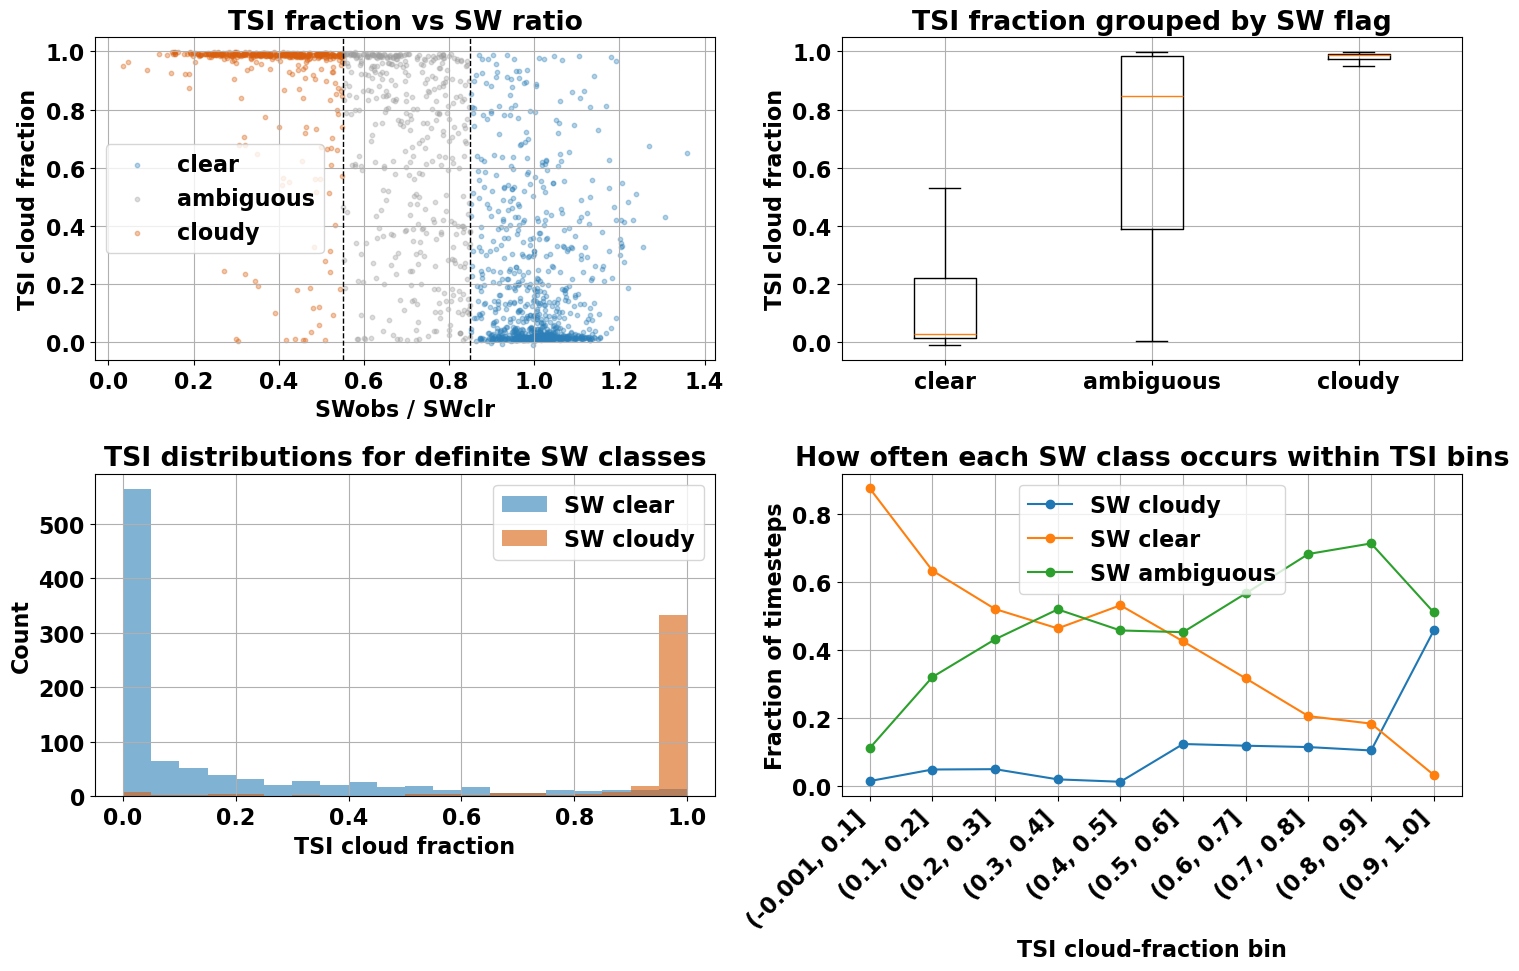

In [92]:
colors = {"clear": "#2c7fb8", "cloudy": "#d95f0e", "ambiguous": "#9e9e9e"}

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for flag in ["clear", "ambiguous", "cloudy"]:
    sub = compare_df[compare_df["sw_flag"] == flag]
    axes[0, 0].scatter(
        sub["sw_ratio"],
        sub["tsi_frac"],
        s=10,
        alpha=0.35,
        label=flag,
        color=colors[flag],
    )
axes[0, 0].axvline(CLOUDY_RATIO, color="k", ls="--", lw=1)
axes[0, 0].axvline(CLEAR_RATIO, color="k", ls="--", lw=1)
axes[0, 0].set_xlabel("SWobs / SWclr")
axes[0, 0].set_ylabel("TSI cloud fraction")
axes[0, 0].set_title("TSI fraction vs SW ratio")
axes[0, 0].legend()

box_data = [
    compare_df.loc[compare_df["sw_flag"] == "clear", "tsi_frac"].dropna(),
    compare_df.loc[compare_df["sw_flag"] == "ambiguous", "tsi_frac"].dropna(),
    compare_df.loc[compare_df["sw_flag"] == "cloudy", "tsi_frac"].dropna(),
]
axes[0, 1].boxplot(box_data, labels=["clear", "ambiguous", "cloudy"], showfliers=False)
axes[0, 1].set_ylabel("TSI cloud fraction")
axes[0, 1].set_title("TSI fraction grouped by SW flag")

axes[1, 0].hist(
    compare_df.loc[compare_df["sw_flag"] == "clear", "tsi_frac"].dropna(),
    bins=np.linspace(0, 1, 21),
    alpha=0.6,
    label="SW clear",
    color=colors["clear"],
)
axes[1, 0].hist(
    compare_df.loc[compare_df["sw_flag"] == "cloudy", "tsi_frac"].dropna(),
    bins=np.linspace(0, 1, 21),
    alpha=0.6,
    label="SW cloudy",
    color=colors["cloudy"],
)
axes[1, 0].set_xlabel("TSI cloud fraction")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("TSI distributions for definite SW classes")
axes[1, 0].legend()

bin_centers = np.arange(len(flag_by_tsi_bin))
axes[1, 1].plot(bin_centers, flag_by_tsi_bin["cloudy_fraction"], marker="o", label="SW cloudy")
axes[1, 1].plot(bin_centers, flag_by_tsi_bin["clear_fraction"], marker="o", label="SW clear")
axes[1, 1].plot(bin_centers, flag_by_tsi_bin["ambiguous_fraction"], marker="o", label="SW ambiguous")
axes[1, 1].set_xticks(bin_centers)
axes[1, 1].set_xticklabels([str(x) for x in flag_by_tsi_bin.index], rotation=45, ha="right")
axes[1, 1].set_xlabel("TSI cloud-fraction bin")
axes[1, 1].set_ylabel("Fraction of timesteps")
axes[1, 1].set_title("How often each SW class occurs within TSI bins")
axes[1, 1].legend()

plt.tight_layout()

In [129]:
example_day = pd.Timestamp("2023-04-30")
day_df = compare_df.loc[compare_df["date"].eq(example_day)].copy()

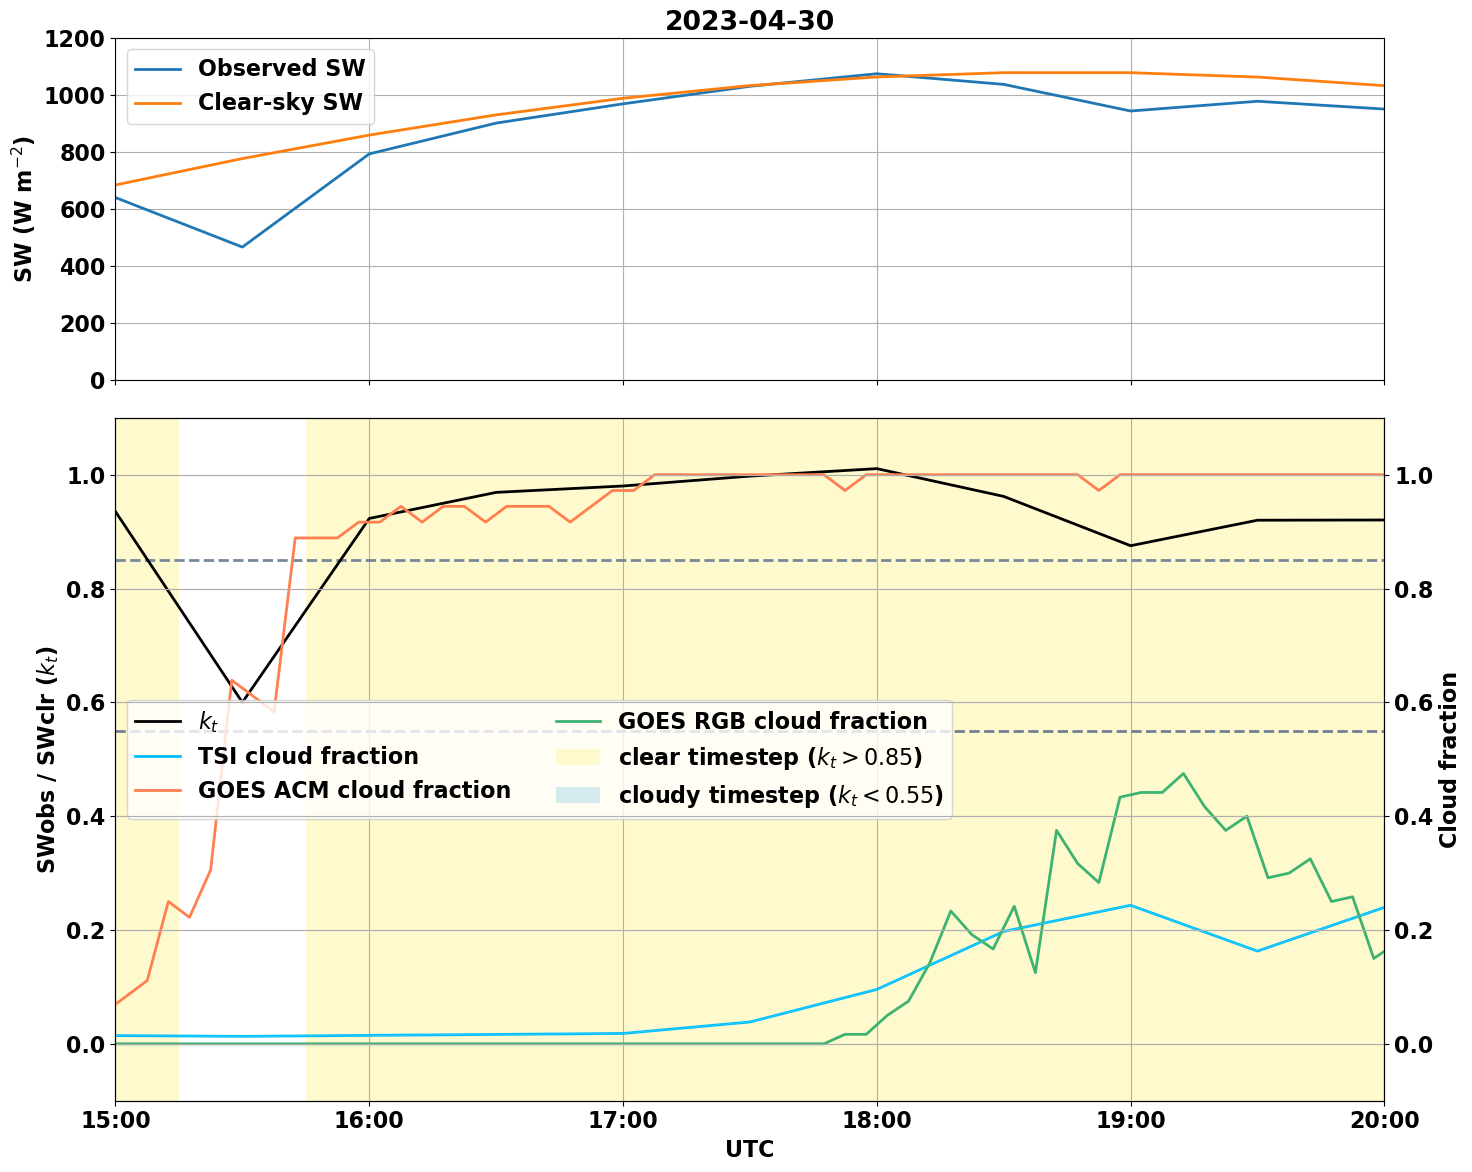

In [130]:
from matplotlib.dates import num2date
from matplotlib.patches import Patch

goes_cf_path = "/glade/u/home/cdalden/goes_work/analysis/output_08c/colorado_domain_cloud_fraction_14z_00z.csv"
goes_cf_df = pd.read_csv(goes_cf_path, parse_dates=["t"])
goes_cf_df["time_local"] = (
    goes_cf_df["t"]
    .dt.tz_localize("UTC")
    .dt.tz_convert(LOCAL_TZ)
    .dt.tz_localize(None)
)
goes_day_df = goes_cf_df.loc[
    goes_cf_df["time_local"].dt.normalize().eq(pd.Timestamp(example_day).normalize())
].copy()

fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True, height_ratios=[1, 2])

axes[0].plot(day_df["time_local"], day_df["sw_obs"], label="Observed SW", lw=2)
axes[0].plot(day_df["time_local"], day_df["sw_clear"], label="Clear-sky SW", lw=2)
axes[0].set_ylabel("SW (W m$^{-2}$)")
axes[0].set_title(f"{example_day.date()}")
axes[0].set_ylim(0,1200)
axes[0].legend()

ax2 = axes[1].twinx()
ax2.plot(day_df["time_local"], day_df["tsi_frac"], label="TSI cloud fraction", lw=0.1, color='white')

shade_half_width = pd.Timedelta(minutes=15)
ratio_clear = day_df["sw_ratio"].gt(CLEAR_RATIO)
ratio_cloudy = day_df["sw_ratio"].lt(CLOUDY_RATIO)
for mask, color, alpha in [
    (ratio_clear, "lemonchiffon", 1.0),
    (ratio_cloudy, "lightblue", 0.5),
]:
    for time in day_df.loc[mask, "time_local"]:
        axes[1].axvspan(
            time - shade_half_width,
            time + shade_half_width,
            color=color,
            alpha=alpha,
            linewidth=0,
            zorder=0,
        )

axes[1].plot(day_df["time_local"], day_df["sw_ratio"], label="$k_t$", lw=2, color='k', zorder=3)
axes[1].plot(day_df["time_local"], day_df["tsi_frac"], label="TSI cloud fraction", lw=2, color='deepskyblue', zorder=4)
axes[1].plot(goes_day_df["time_local"], goes_day_df["acm_cloud_frac"], label="GOES ACM cloud fraction", lw=2, color="coral", zorder=4)
axes[1].plot(goes_day_df["time_local"], goes_day_df["rgb_cloud_frac"], label="GOES RGB cloud fraction", lw=2, color="mediumseagreen", zorder=4)
axes[1].axhline(CLOUDY_RATIO, color='slategray', ls="--", lw=2, zorder=2)
axes[1].axhline(CLEAR_RATIO, color='lightslategray', ls="--", lw=2, zorder=2)
axes[1].set_ylabel("SWobs / SWclr ($k_t$)")
ax2.set_ylabel("Cloud fraction")
axes[1].set_ylim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
handles, labels = axes[1].get_legend_handles_labels()
handles.extend([
    Patch(facecolor="lemonchiffon", edgecolor="none", label="clear timestep ($k_t > 0.85$)"),
    Patch(facecolor="lightblue", edgecolor="none", alpha=0.5, label="cloudy timestep ($k_t < 0.55$)"),
])
axes[1].legend(handles=handles, ncol=2)

utc_offset = pd.Timestamp(example_day).tz_localize(LOCAL_TZ).utcoffset()
utc_xlim_start = pd.Timestamp(example_day).normalize() + pd.Timedelta(hours=15) + utc_offset
utc_xlim_end = pd.Timestamp(example_day).normalize() + pd.Timedelta(hours=20) + utc_offset
axes[1].set_xlim(utc_xlim_start, utc_xlim_end)
axes[1].xaxis.set_major_formatter(
    lambda x, pos: (pd.Timestamp(num2date(x)).tz_localize(None) - utc_offset).strftime("%H:%M")
)
axes[1].set_xlabel("UTC")

plt.tight_layout()

In [95]:
day_table = day_df[["time_local", "sw_obs", "sw_clear", "sw_ratio", "tsi_frac", "sw_flag"]].copy()
for col in ["sw_obs", "sw_clear", "sw_ratio", "tsi_frac"]:
    day_table[col] = day_table[col].round(3)
day_table.head(20)

,time_local,sw_obs,sw_clear,sw_ratio,tsi_frac,sw_flag
2288,2023-05-28 09:00:00,665.823975,746.107,0.892,0.030,clear
2289,2023-05-28 09:30:00,761.244019,834.632,0.912,0.047,clear
2290,2023-05-28 10:00:00,872.630005,913.518,0.955,0.178,clear
2291,2023-05-28 10:30:00,415.230011,981.413,0.423,0.549,cloudy
2292,2023-05-28 11:00:00,362.381989,1037.156,0.349,0.648,cloudy
2293,2023-05-28 11:30:00,801.086975,1079.794,0.742,0.296,ambiguous
2294,2023-05-28 12:00:00,850.338989,1108.597,0.767,0.262,ambiguous
2295,2023-05-28 12:30:00,933.541992,1123.072,0.831,0.400,ambiguous
2296,2023-05-28 13:00:00,838.116028,1122.971,0.746,0.376,ambiguous
2297,2023-05-28 13:30:00,1097.621948,1108.297,0.990,0.334,clear


In [96]:
# Days where calibrated clear-sky SW is still lower than observed SW
RATIO_EXCEEDANCE_THRESHOLD = 1.0
OUT_RATIO_EXCEEDANCE_DATES = "sw_ratio_gt1_candidate_dates.csv"

ratio_exceedance_df = compare_df.loc[
    compare_df["sw_ratio"].gt(RATIO_EXCEEDANCE_THRESHOLD)
].copy()

daily_ratio_exceedance = (
    compare_df.assign(ratio_gt1=compare_df["sw_ratio"].gt(RATIO_EXCEEDANCE_THRESHOLD))
    .groupby("date")
    .agg(
        n_total=("sw_ratio", "size"),
        n_ratio_gt1=("ratio_gt1", "sum"),
        max_ratio=("sw_ratio", "max"),
        mean_ratio=("sw_ratio", "mean"),
        median_ratio=("sw_ratio", "median"),
        max_obs_sw=("sw_obs", "max"),
        max_clear_sw=("sw_clear", "max"),
        mean_tsi_frac=("tsi_frac", "mean"),
        min_tsi_frac=("tsi_frac", "min"),
    )
)
daily_ratio_exceedance["frac_ratio_gt1"] = daily_ratio_exceedance["n_ratio_gt1"] / daily_ratio_exceedance["n_total"]

daily_ratio_exceedance = (
    daily_ratio_exceedance.loc[daily_ratio_exceedance["n_ratio_gt1"] > 0]
    .sort_values(["max_ratio", "frac_ratio_gt1", "n_ratio_gt1"], ascending=False)
    .reset_index()
)
daily_ratio_exceedance["date"] = daily_ratio_exceedance["date"].dt.date
daily_ratio_exceedance.to_csv(OUT_RATIO_EXCEEDANCE_DATES, index=False)

print(f"Days with SWobs/SWclr > {RATIO_EXCEEDANCE_THRESHOLD}: {len(daily_ratio_exceedance)}")
print(f"Saved ranked candidate dates to {OUT_RATIO_EXCEEDANCE_DATES}")
daily_ratio_exceedance.head(25).round(3)


Days with SWobs/SWclr > 1.0: 113
Saved ranked candidate dates to sw_ratio_gt1_candidate_dates.csv


,date,n_total,n_ratio_gt1,max_ratio,mean_ratio,median_ratio,max_obs_sw,max_clear_sw,mean_tsi_frac,min_tsi_frac,frac_ratio_gt1
0,2022-12-07,11,1,1.359,1.015,1.015,665.950012,531.511,0.878,0.608,0.091
1,2023-03-24,11,4,1.307,0.880,0.875,1019.525024,934.231,0.465,0.182,0.364
2,2022-11-14,11,2,1.269,0.812,0.836,753.354004,608.020,0.759,0.393,0.182
3,2022-11-15,11,9,1.255,1.066,1.120,728.554016,603.461,0.275,0.034,0.818
4,2023-04-05,11,8,1.238,0.992,1.136,1229.368042,992.973,0.305,0.100,0.727
5,2023-01-25,11,4,1.220,0.862,0.830,735.398987,602.673,0.759,0.187,0.364
6,2022-12-24,11,5,1.211,1.008,1.022,594.710022,519.287,0.550,0.206,0.455
7,2022-11-04,11,6,1.210,0.911,1.006,747.937012,658.173,0.204,0.025,0.545
8,2023-04-26,11,5,1.205,0.994,1.002,1288.373047,1068.886,0.611,0.393,0.455
9,2023-02-06,11,7,1.204,0.999,1.011,787.601013,662.933,0.321,0.015,0.636


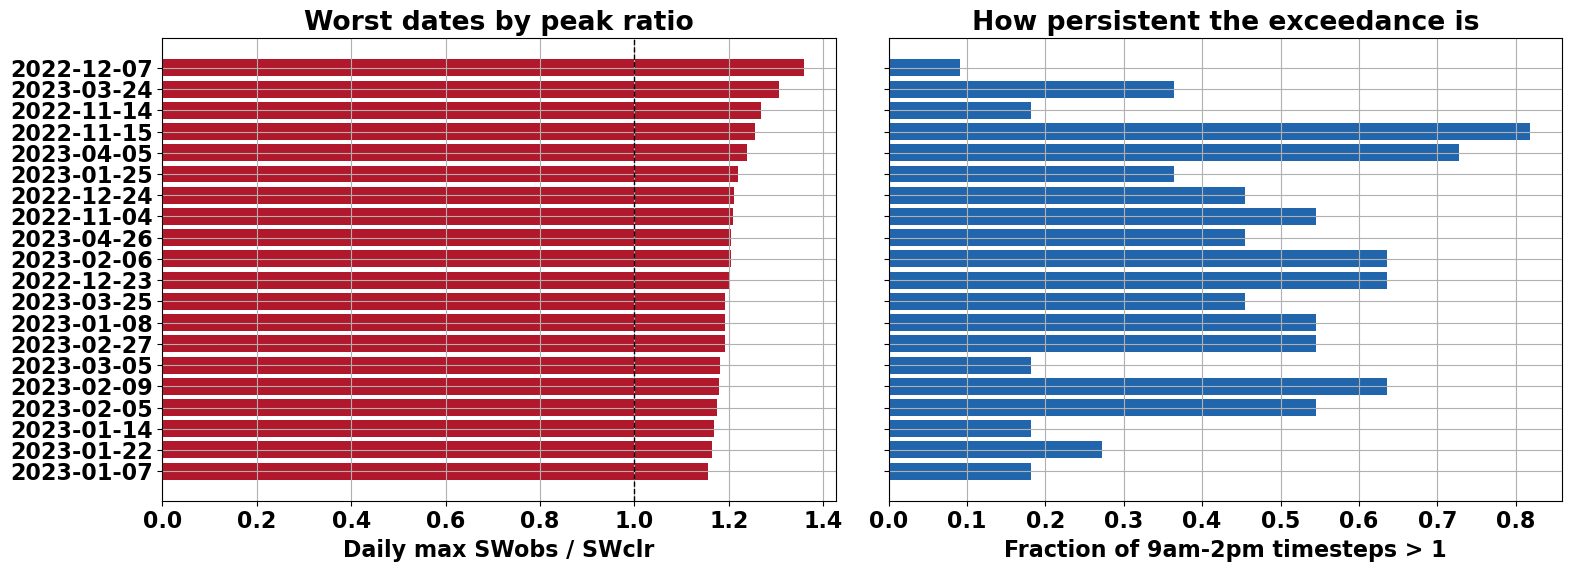

In [97]:
top_n = 20
plot_df = daily_ratio_exceedance.head(top_n).copy()
plot_df["date_label"] = plot_df["date"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

axes[0].barh(plot_df["date_label"], plot_df["max_ratio"], color="#b2182b")
axes[0].axvline(RATIO_EXCEEDANCE_THRESHOLD, color="k", ls="--", lw=1)
axes[0].invert_yaxis()
axes[0].set_xlabel("Daily max SWobs / SWclr")
axes[0].set_title("Worst dates by peak ratio")

axes[1].barh(plot_df["date_label"], plot_df["frac_ratio_gt1"], color="#2166ac")
axes[1].set_xlabel("Fraction of 9am-2pm timesteps > 1")
axes[1].set_title("How persistent the exceedance is")

plt.tight_layout()


In [98]:
# Days where the SW method says cloudy but TSI cloud fraction is low
LOW_TSI_CLOUD_FRACTION_THRESHOLD = 0.20
OUT_SW_CLOUDY_LOW_TSI_DATES = "sw_cloudy_low_tsi_candidate_dates.csv"

sw_cloudy_low_tsi_df = compare_df.loc[
    (compare_df["sw_flag"] == "cloudy")
    & compare_df["tsi_frac"].lt(LOW_TSI_CLOUD_FRACTION_THRESHOLD)
].copy()

daily_sw_cloudy_low_tsi = (
    sw_cloudy_low_tsi_df.groupby("date")
    .agg(
        n_mismatch=("time_local", "size"),
        min_sw_ratio=("sw_ratio", "min"),
        mean_sw_ratio=("sw_ratio", "mean"),
        max_tsi_frac=("tsi_frac", "max"),
        mean_tsi_frac=("tsi_frac", "mean"),
        min_obs_sw=("sw_obs", "min"),
        mean_obs_sw=("sw_obs", "mean"),
        mean_clear_sw=("sw_clear", "mean"),
        first_time=("time_local", "min"),
        last_time=("time_local", "max"),
    )
    .sort_values(["n_mismatch", "min_sw_ratio", "mean_tsi_frac"], ascending=[False, True, True])
    .reset_index()
)
daily_sw_cloudy_low_tsi["date"] = daily_sw_cloudy_low_tsi["date"].dt.date
daily_sw_cloudy_low_tsi.to_csv(OUT_SW_CLOUDY_LOW_TSI_DATES, index=False)

print(
    f"Days with SW cloudy and TSI fraction < {LOW_TSI_CLOUD_FRACTION_THRESHOLD}: "
    f"{len(daily_sw_cloudy_low_tsi)}"
)
print(f"Saved ranked candidate dates to {OUT_SW_CLOUDY_LOW_TSI_DATES}")
display_cols = daily_sw_cloudy_low_tsi.head(25).copy()
numeric_cols = display_cols.select_dtypes(include="number").columns
display_cols[numeric_cols] = display_cols[numeric_cols].round(3)
display_cols


Days with SW cloudy and TSI fraction < 0.2: 17
Saved ranked candidate dates to sw_cloudy_low_tsi_candidate_dates.csv


,date,n_mismatch,min_sw_ratio,mean_sw_ratio,max_tsi_frac,mean_tsi_frac,min_obs_sw,mean_obs_sw,mean_clear_sw,first_time,last_time
0,2023-04-02,1,0.301,0.301,0.010,0.010,171.572006,171.572006,570.554,2023-04-02 09:00:00,2023-04-02 09:00:00
1,2023-04-07,1,0.304,0.304,0.004,0.004,180.492996,180.492996,594.634,2023-04-07 09:00:00,2023-04-07 09:00:00
2,2022-11-10,1,0.351,0.351,0.194,0.194,220.302002,220.302002,627.101,2022-11-10 12:00:00,2022-11-10 12:00:00
3,2023-04-05,1,0.390,0.390,0.100,0.100,228.511002,228.511002,585.477,2023-04-05 09:00:00,2023-04-05 09:00:00
4,2023-04-16,1,0.416,0.416,0.006,0.006,263.921997,263.921997,634.464,2023-04-16 09:00:00,2023-04-16 09:00:00
5,2023-03-29,1,0.439,0.439,0.011,0.011,241.985001,241.985001,551.195,2023-03-29 09:00:00,2023-03-29 09:00:00
6,2022-11-27,1,0.444,0.444,0.178,0.178,247.313995,247.313995,557.053,2022-11-27 11:30:00,2022-11-27 11:30:00
7,2023-04-10,1,0.456,0.456,0.005,0.005,277.751007,277.751007,608.882,2023-04-10 09:00:00,2023-04-10 09:00:00
8,2023-04-11,1,0.461,0.461,0.006,0.006,282.178009,282.178009,612.433,2023-04-11 09:00:00,2023-04-11 09:00:00
9,2023-04-08,1,0.473,0.473,0.188,0.188,283.630005,283.630005,599.979,2023-04-08 09:00:00,2023-04-08 09:00:00
